In [ ]:
%load_ext autoreload
%autoreload 2
import eq
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import copy
import numpy as np

base_dir = Path(eq.__file__).parent.parent
results_dir = base_dir / 'results' / "AGU25"

In [2]:
!rm -rf /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog
catalog = eq.catalogs.ANSS_MultiCatalog(    
    num_sequences=5000,
    t_end_days=365,
    radius_kilometers=250,
    mag_completeness=4.5,
    minimum_mainshock_mag=6.5,
)
# TODO: create config for catalog so that all the notebooks don't need to match

Generating the catalog...
Downloading/loading...


/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:173: UserWarning: Using existing /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/raw/anss_global_catalog.csv
  warnings.warn(f"Using existing {filename}")
/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:179: UserWarning: 248 NaN values found in catalog. Removing rows with NaN values.
  warnings.warn(


train


100%|██████████| 3000/3000 [00:05<00:00, 503.82it/s]


val


100%|██████████| 1000/1000 [00:01<00:00, 501.43it/s]


test


100%|██████████| 1000/1000 [00:02<00:00, 486.91it/s]


Success!
Catalog saved to /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog


The global anss catalog is a collection of 5000 sequences from the ANSS catalog. We need to train an ETAS model for each sequence. Specifically, the ETAS model is trained on the conditioning period of each sequence (before the t_nll_start).

Here are a few examples of the sequences in the catalog:

For now we will use the first sequence in the validation set to test the approach. Here the ETAS model will be trained is a manner more consistent with standard practice in OAF. 

In the immediate wake of a large earthquake (in this case the fist 6.5+ event in the validatation interval), we train the ETAS model on the history of the sequence up to that point.

Note that we consider the first 6.5+ event in the validation interval to be the mainshock to maintain the possibility of having larger events in the forecasts interval.

In [245]:
val_index = 120
forecast_interval_duration = 2*7 # 2 weeks
forecast_latency_duration = 1/24/60 * 10 
number_of_forecasts = 20000
mainshock_mag = 6.5

In [246]:
seq = catalog.val[val_index]
mainshocks_time = seq.arrival_times[(seq.mag >= mainshock_mag) & (seq.arrival_times > seq.t_nll_start)].min() 
forecast_start_time = mainshocks_time + forecast_latency_duration

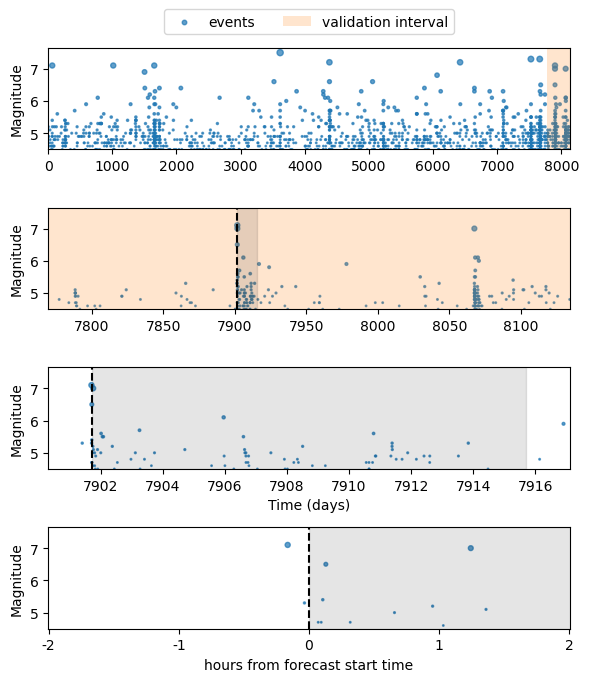

In [247]:
fig, AX = plt.subplots(4,1, figsize=(6,7), dpi=100)

buffer = 0.1

eq.visualization.visualize_sequence(seq, show_nll=True, ax=AX[0])
AX[0].set(
    xlabel='',
)

eq.visualization.visualize_sequence(seq, show_nll=True, ax=AX[1])
AX[1].axvline(forecast_start_time, color='k', linestyle='--')
AX[1].axvspan(forecast_start_time, forecast_start_time + forecast_interval_duration, color='k', alpha=0.1)
AX[1].set(
    xlim=(seq.t_nll_start, seq.t_end),
    xlabel='',
)

eq.visualization.visualize_sequence(seq, show_nll=False, ax=AX[2])
AX[2].axvline(forecast_start_time, color='k', linestyle='--')
AX[2].axvspan(forecast_start_time, forecast_start_time + forecast_interval_duration, color='k', alpha=0.1)
AX[2].set(
    xlim=(forecast_start_time - (buffer*forecast_interval_duration), forecast_start_time + ((1+buffer)*forecast_interval_duration)),
    xlabel="Time (days)",
)


# +/- two hours from the forecast start time 
number_of_hours = 2
hour_tick_labels = np.arange(number_of_hours*2 + 1) - number_of_hours
hour_ticks = forecast_start_time + hour_tick_labels * 1/24

eq.visualization.visualize_sequence(seq, show_nll=False, ax=AX[3])
AX[3].axvline(forecast_start_time, color='k', linestyle='--')
AX[3].axvspan(forecast_start_time, forecast_start_time + forecast_interval_duration, color='k', alpha=0.1)
AX[3].set(
    xlim=(forecast_start_time - number_of_hours/24, forecast_start_time + number_of_hours/24),
    xticks = hour_ticks,
    xticklabels = hour_tick_labels,
    xlabel='hours from forecast start time',
)

AX[0].legend(["events", "validation interval"], loc='upper center', bbox_to_anchor=(0.5, 1.45), ncol=2)
for iax in AX[1:]:
    legend = iax.get_legend()
    legend.remove()

plt.tight_layout()


In [248]:
seq = copy.deepcopy(catalog.val[val_index])
train_end_time = forecast_start_time
seq.t_nll_start = seq.t_start
train_seq = seq.get_subsequence(0, train_end_time)
train_seq.t_nll_start = 365 # allow for 1 year burn in period 
val_seq = catalog.val[val_index]

batch = eq.data.Batch.from_list([train_seq])
val_batch = eq.data.Batch.from_list([val_seq])

etas_model = eq.models.ETAS(
    mag_completeness=catalog.metadata["mag_completeness"],
    base_rate_init=10**torch.mean(torch.log(batch.inter_times))/10, # geometric mean and heuristic guess
)

optimizer = torch.optim.Adam(etas_model.parameters(), lr=3e-1)

number_of_epochs = 1000

train_loss = []
val_loss = []
mus = []
alphas = []
cs = []
ps = []
ks = []
for epoch in range(number_of_epochs):
    loss = etas_model.nll_loss(batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss.append(loss.item())
    
    with torch.no_grad():
        val_loss.append(etas_model.nll_loss(val_batch).item())
    
    # Track parameters at each epoch
    mus.append(etas_model.mu.item())
    alphas.append(etas_model.alpha.item())
    cs.append(etas_model.c.item())
    ps.append(etas_model.p.item())
    ks.append(etas_model.k.item())


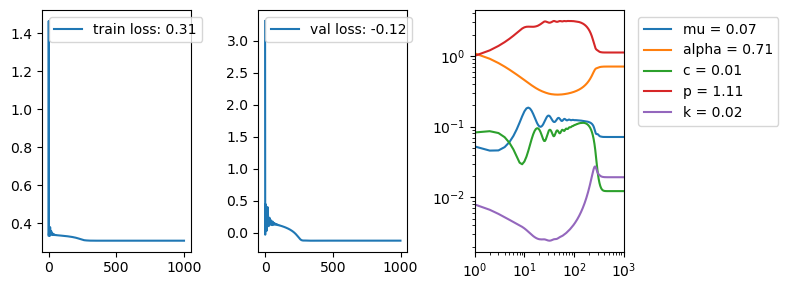

In [249]:
fig, ax = plt.subplots(1,3, figsize=(8,3))
ax[0].plot(train_loss, label=f'train loss: {train_loss[-1]:.2f}')
ax[0].legend()

ax[1].plot(val_loss, label=f'val loss: {val_loss[-1]:.2f}')
ax[1].legend()

for param, label in zip([mus, alphas, cs, ps, ks], ['mu', 'alpha', 'c', 'p', 'k']):
    ax[2].plot(param, label=f"{label} = {param[-1]:.2f}")

ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[2].set(
    yscale='log',
    xlim=(1, number_of_epochs),
    xscale='log'
)
plt.tight_layout()

Now we can see how well ETAS performs in the forecasting interval. This is our benchmark NLL performance.

In [250]:
batch = eq.data.Batch.from_list([catalog.val[val_index]])
with torch.no_grad():
    nll = etas_model.nll_loss(batch)
    print(f"NLL: {nll.item()}")

NLL: -0.12098176032304764


More importantly, we can see how well the ETAS simulations compare to the observed data. So we first sample a collection of catalog continuations from the trained ETAS model.

In [251]:
etas_forecasts = etas_model.sample(batch_size=10000, past_seq=train_seq, duration=forecast_interval_duration)

  0%|          | 0/10000 [00:00<?, ?it/s]

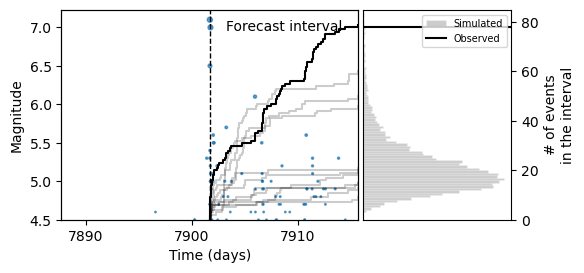

[(0.0, 78.0)]

In [252]:
AX = eq.visualization.visualize_trajectories(catalog.val[val_index], etas_forecasts.to_list())

ax[0].set(ylim=(0, len(catalog.val[val_index].get_subsequence(forecast_start_time, forecast_start_time + forecast_interval_duration))))
ax[0].set(ylim=(0, len(catalog.val[val_index].get_subsequence(forecast_start_time, forecast_start_time + forecast_interval_duration))))

We can now pull a trained recast model and see how it performs on the same sequence. In practive will will want to retrain the model for each sequence and compare the collective performances. 

In [253]:
# load trained RECAST model
best_model_path = "/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/notebooks/lightning_logs/version_45/checkpoints/epoch=148-step=4470.ckpt" 
recast_model = eq.models.RecurrentTPP.load_from_checkpoint(best_model_path)
recast_model.eval()

# evaluate on the same sequence
with torch.no_grad():
    recast_nll = recast_model.nll_loss(eq.data.Batch.from_list([catalog.val[val_index]])).item()

print(f"NLL: {recast_nll}")

NLL: -0.17714159190654755


In [254]:
recast_forecasts = recast_model.sample(batch_size=10000, past_seq=train_seq, duration=forecast_interval_duration)

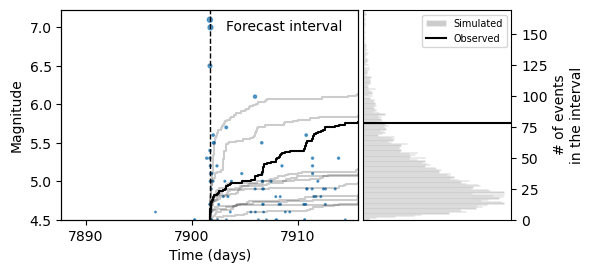

[(0.0, 78.0)]

In [255]:
AX = eq.visualization.visualize_trajectories(catalog.val[val_index], recast_forecasts.to_list())

ax[0].set(ylim=(0, len(catalog.val[val_index].get_subsequence(forecast_start_time, forecast_start_time + forecast_interval_duration))))
ax[0].set(ylim=(0, len(catalog.val[val_index].get_subsequence(forecast_start_time, forecast_start_time + forecast_interval_duration))))


Text(0.01, 0.99, 'ETAS')

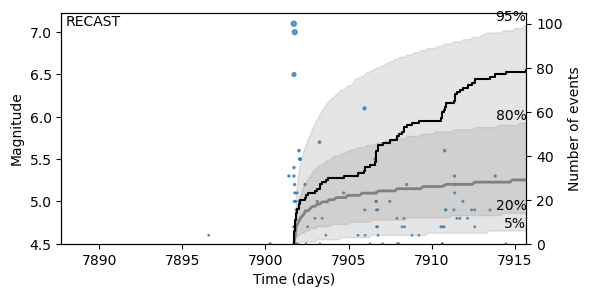

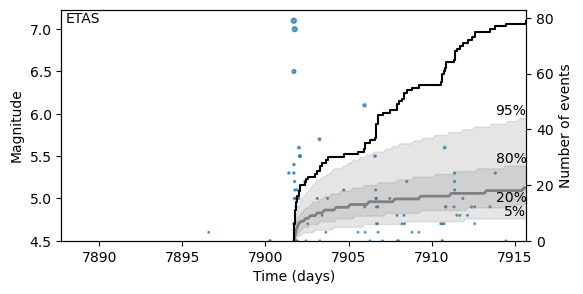

In [ ]:
ax = eq.visualization.visualize_forecasts(
    catalog.val[val_index],
    recast_forecasts.to_list(),
    plot_observed_trajectory=True,
)
ax.text(0.01, 0.99, 'RECAST', transform=ax.transAxes, ha='left', va='top')

ax = eq.visualization.visualize_forecasts(
    catalog.val[val_index],
    etas_forecasts.to_list(),
    plot_observed_trajectory=True,
)

ax.text(0.01, 0.99, 'ETAS', transform=ax.transAxes, ha='left', va='top')
